In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc

In [10]:
OUT_PUT = "./data/train.parquet"

df = pd.read_parquet("data/flight.parquet", engine="pyarrow")
df

,flight,payload,route,altitude_preset,date,time_day,duration_s,total_distance_m,wind_speed_mean,wind_speed_std,...,velocity_mag_max,acceleration_mag_mean,acceleration_mag_std,battery_voltage_mean,battery_voltage_min,max_height_agl,final_height_agl,energy_consumed_Wh,battery_needed_mAh,landing_offset_flag
0,1,0.0,R5,25,2019-04-07,10:13,200.70,549.065984,3.898058,1.952675,...,6.261616,9.842870,0.466372,22.070134,21.228519,26.257755,-0.994409,21.769975,1000.743935,False
1,2,0.0,R5,50,2019-04-07,10:23,271.20,666.615556,3.522941,2.159456,...,7.676739,9.881874,0.628406,21.527547,20.125463,52.637988,0.589477,25.366627,1205.255874,False
2,3,0.0,R5,25,2019-04-07,10:33,180.10,577.009957,4.581182,3.335733,...,7.213987,9.902090,0.545290,22.330305,19.943916,24.660462,0.106140,17.094392,789.073853,False
3,4,0.0,R5,25,2019-04-07,10:48,171.00,562.802357,4.596319,3.438072,...,9.425537,9.900368,0.559073,21.950616,20.365856,25.580572,0.416669,14.690038,687.813976,False
4,5,0.0,R2,25,2019-04-07,11:05,217.00,470.978276,3.333910,2.247522,...,4.900079,9.817243,0.341981,21.519937,18.923494,24.323036,-0.924901,19.019928,920.070980,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,275,500.0,R1,25,2019-10-24,9:05,149.40,518.231162,4.139878,3.885389,...,8.788151,9.850903,0.420902,22.056616,20.332052,21.959932,-3.264891,16.295811,760.480643,False
205,276,500.0,R1,25,2019-10-24,9:32,147.90,517.758034,4.392581,4.332293,...,10.553163,9.862172,0.471081,21.492353,19.788662,22.542598,1.293232,15.392088,738.620356,False
206,277,500.0,R1,25,2019-10-24,9:45,134.81,517.677109,5.524651,4.029744,...,10.579715,9.847796,0.529103,21.908016,19.352947,24.289124,-0.286362,15.531389,741.451254,False
207,278,500.0,R7,25-50-100-25,2019-10-24,10:00,186.39,545.413261,4.686967,3.826570,...,10.376503,9.829065,0.456918,22.394109,20.407175,95.041887,-0.457578,18.922540,887.198699,False


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   flight                 209 non-null    int64   
 1   payload                209 non-null    float64 
 2   route                  209 non-null    category
 3   altitude_preset        209 non-null    string  
 4   date                   209 non-null    str     
 5   time_day               209 non-null    str     
 6   duration_s             209 non-null    float64 
 7   total_distance_m       209 non-null    float64 
 8   wind_speed_mean        209 non-null    float64 
 9   wind_speed_std         209 non-null    float64 
 10  wind_x_mean            209 non-null    float64 
 11  wind_y_mean            209 non-null    float64 
 12  speed_mean             209 non-null    float64 
 13  speed_max              209 non-null    float64 
 14  velocity_mag_mean      209 non-null    float64 
 15  

In [8]:
del df
gc.collect()
%whos

Variable      Type         Data/Info
------------------------------------
OUT_PUT       str          ./data/train.parquet
corr          DataFrame    Shape: (21, 21)
gc            module       <module 'gc' (built-in)>
mask          ndarray      20x20: 400 elems, type `bool`, 400 bytes
np            module       <module 'numpy' from '/ho<...>kages/numpy/__init__.py'>
num_cols      Index        Index(['flight', 'payload<...>Ah'],\n      dtype='str')
pd            module       <module 'pandas' from '/h<...>ages/pandas/__init__.py'>
plt           module       <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
sns           module       <module 'seaborn' from '/<...>ges/seaborn/__init__.py'>
target_corr   Series       Shape: (20,)


In [14]:
df.columns

Index(['flight', 'payload', 'route', 'altitude_preset', 'date', 'time_day',
       'duration_s', 'total_distance_m', 'wind_speed_mean', 'wind_speed_std',
       'wind_x_mean', 'wind_y_mean', 'speed_mean', 'speed_max',
       'velocity_mag_mean', 'velocity_mag_max', 'acceleration_mag_mean',
       'acceleration_mag_std', 'battery_voltage_mean', 'battery_voltage_min',
       'max_height_agl', 'final_height_agl', 'energy_consumed_Wh',
       'battery_needed_mAh', 'landing_offset_flag'],
      dtype='str')

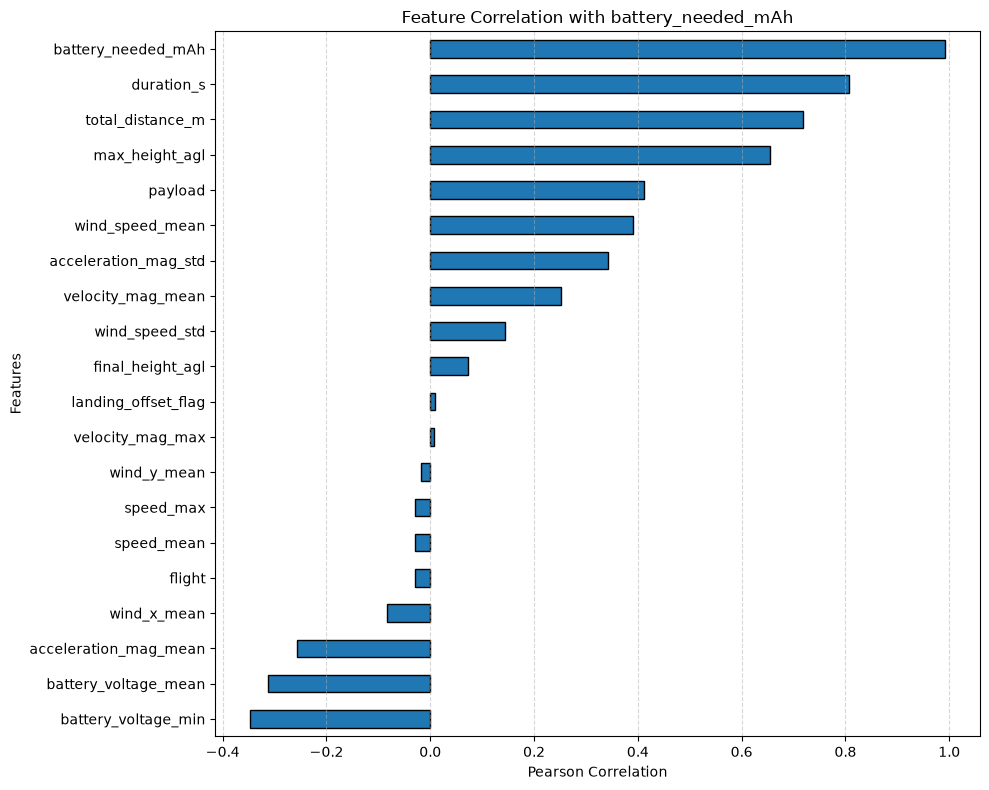

In [13]:
# Compute correlation matrix
corr = df.corr(numeric_only=True)

# Correlation with target
target_corr = (
    corr["energy_consumed_Wh"]
    .drop("energy_consumed_Wh")      # Remove self-correlation
    .sort_values()
)

plt.figure(figsize=(10, 8))

target_corr.plot(
    kind="barh",                  # Horizontal bar chart
    edgecolor="black"
)

plt.title("Feature Correlation with battery_needed_mAh")
plt.xlabel("Pearson Correlation")
plt.ylabel("Features")

plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

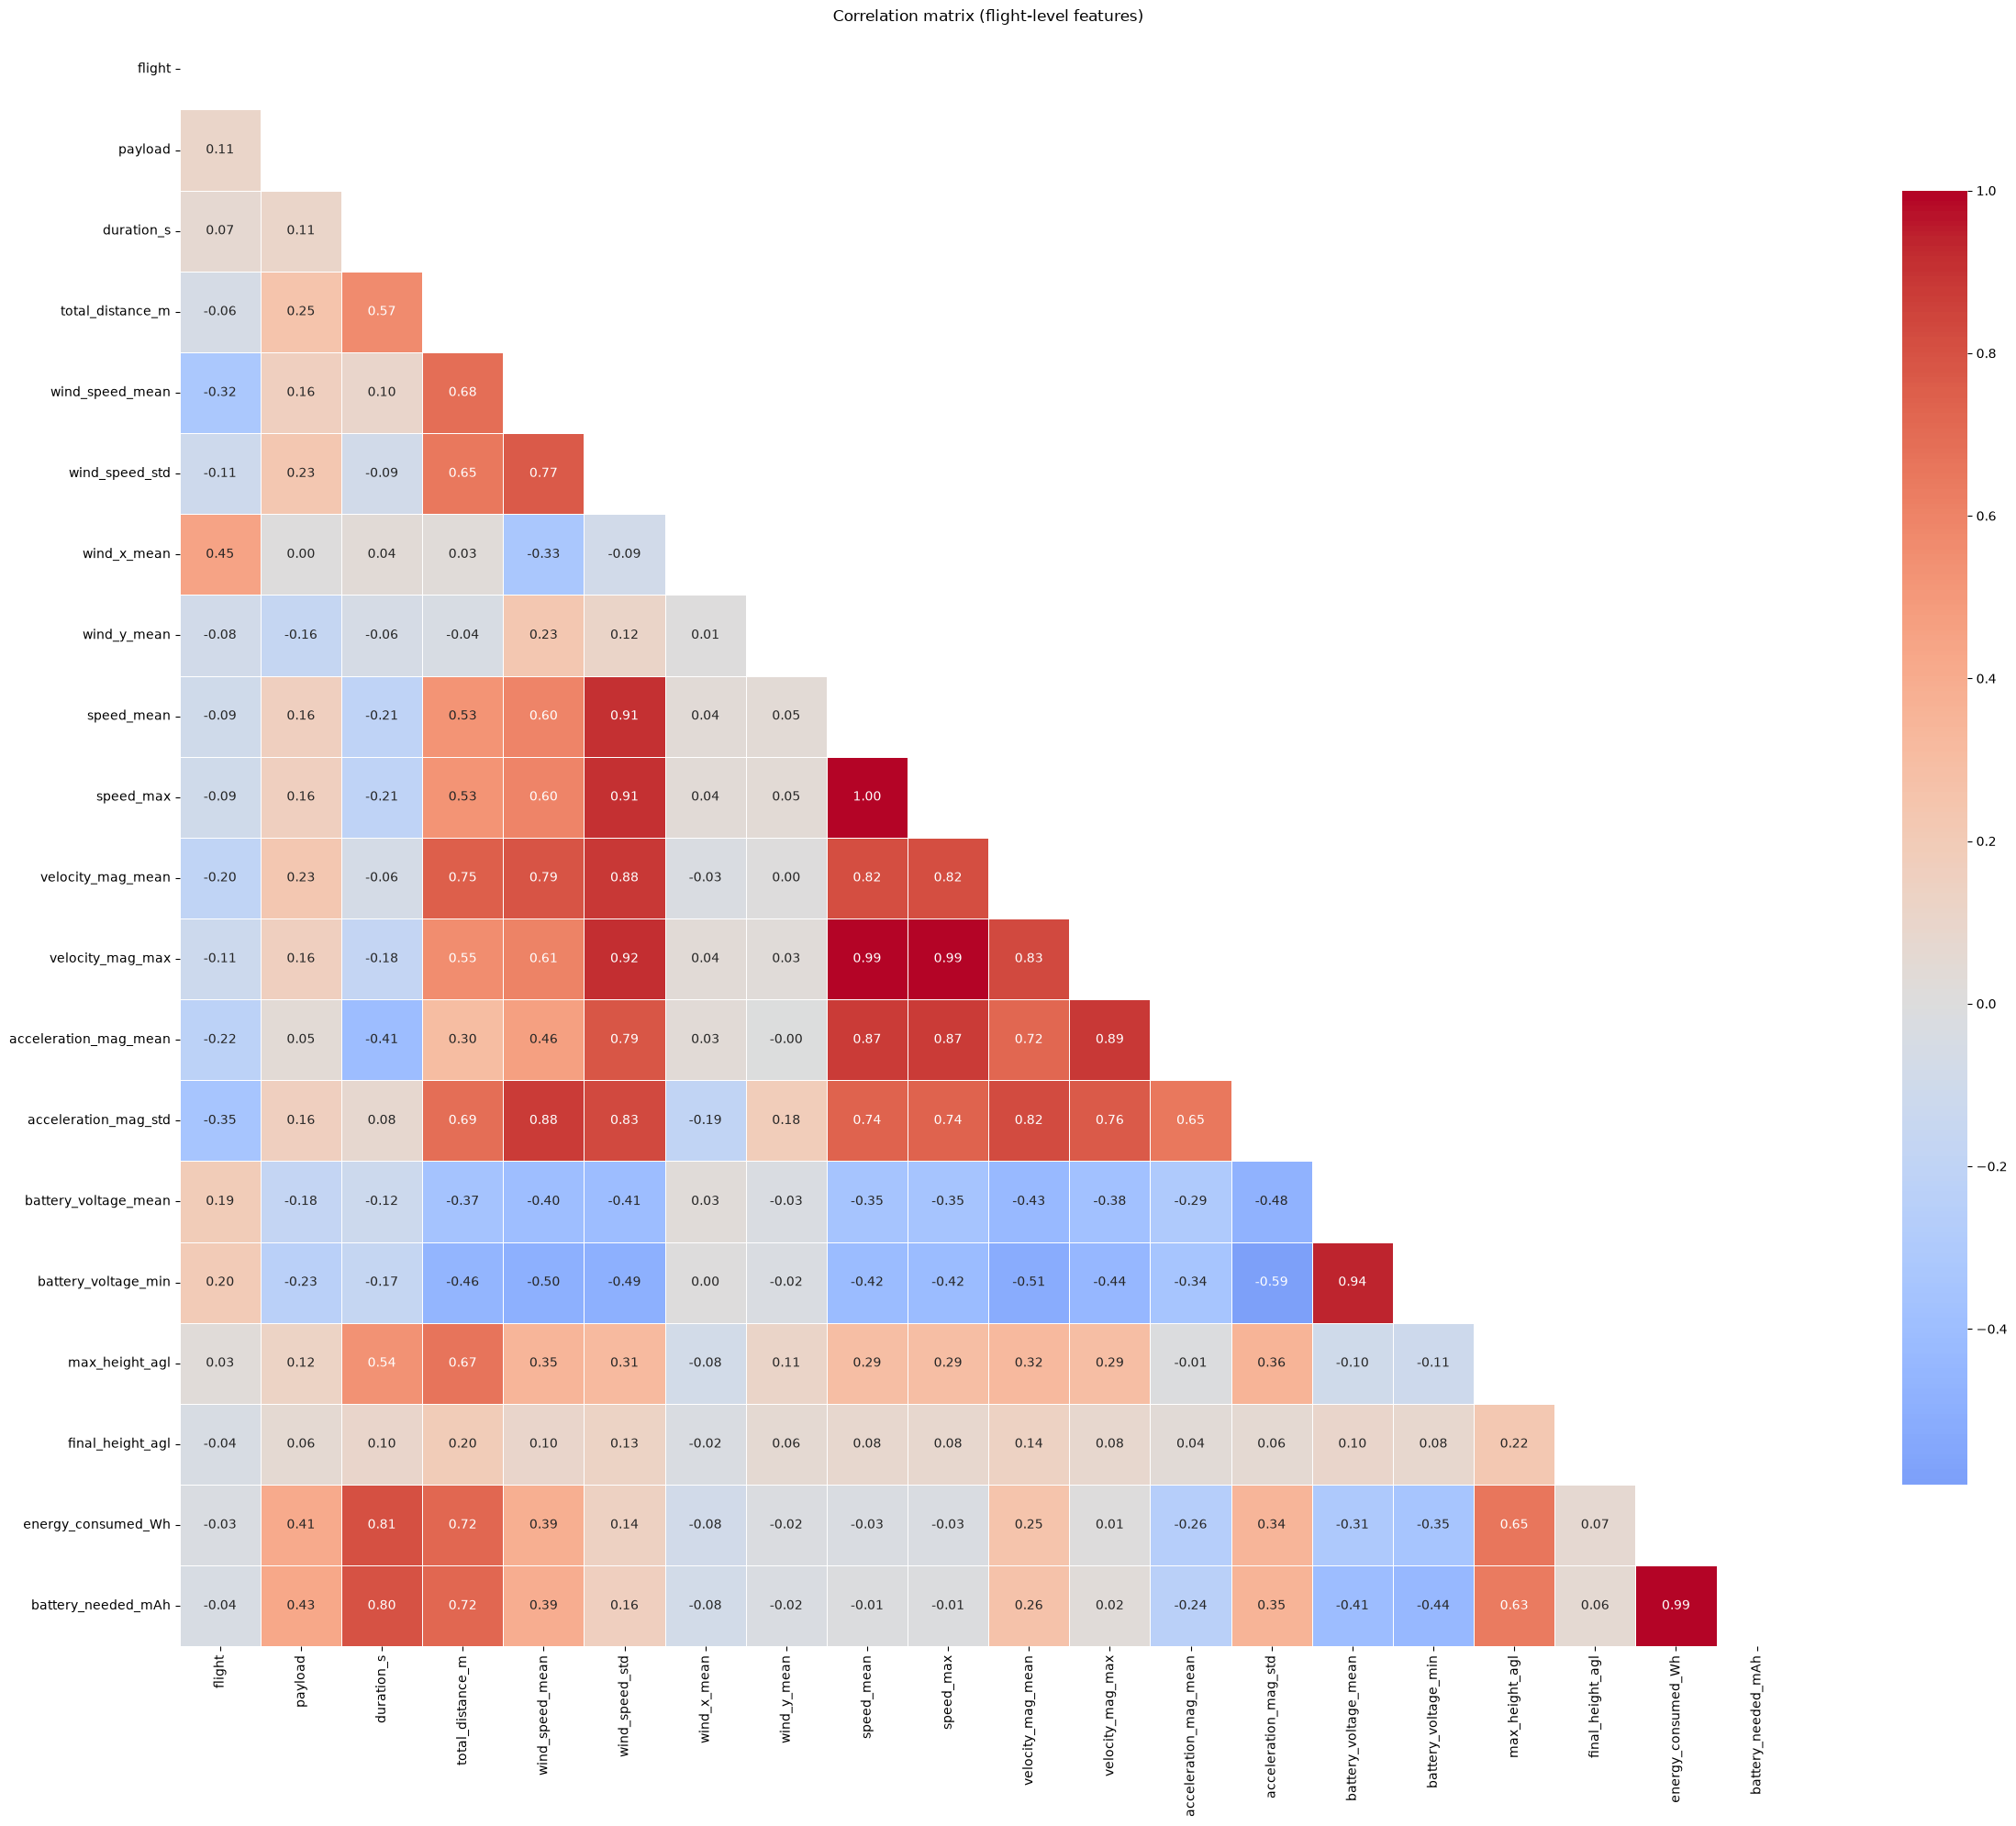

In [6]:
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(25, 20))
sns.heatmap(corr,
        mask=mask,
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5,
        annot= True,
        fmt='.2f',
        cbar_kws={"shrink": 0.8}
            )
plt.title("Correlation matrix (flight-level features)")
plt.tight_layout()
plt.show()